<a href="https://colab.research.google.com/github/hanaafrin1/codsoft/blob/main/Untitled3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving advertising.csv to advertising.csv
✅ Dataset loaded: (200, 4)
      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9

📋 Missing Values:
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

📈 Statistics:
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.846809   21.778621    5.283892
min      0.700000    0.000000    0.300000    1.600000
25%     74.375000    9.975000   12.750000   11.000000
50%    149.750000   22.900000   25.750000   16.000000
75%    218.825000   36.525000   45.100000   19.050000
max    296.400000   49.600000  114.000000   27.000000


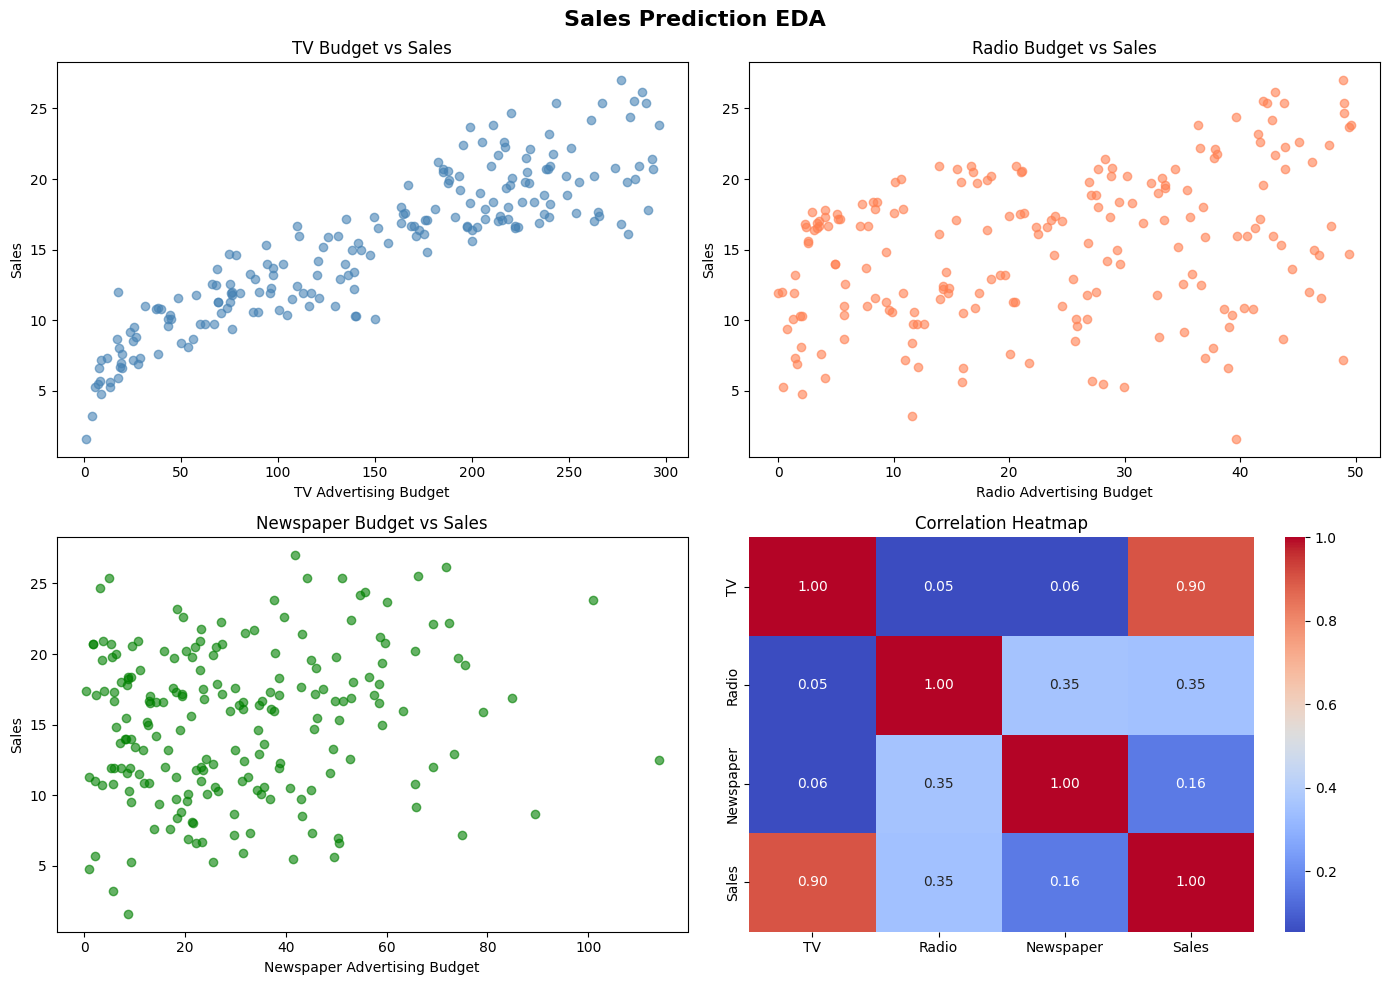

✅ EDA plots saved!

📐 Train: 160 rows | Test: 40 rows

🔵 Linear Regression  → R² Score: 0.9059 | MAE: 1.2748
🟢 Random Forest      → R² Score: 0.9535 | MAE: 0.9180

📊 Random Forest Evaluation:
   R² Score : 0.9535  (closer to 1.0 = better)
   MAE      : 0.9180  (average error in sales units)
   RMSE     : 1.1989


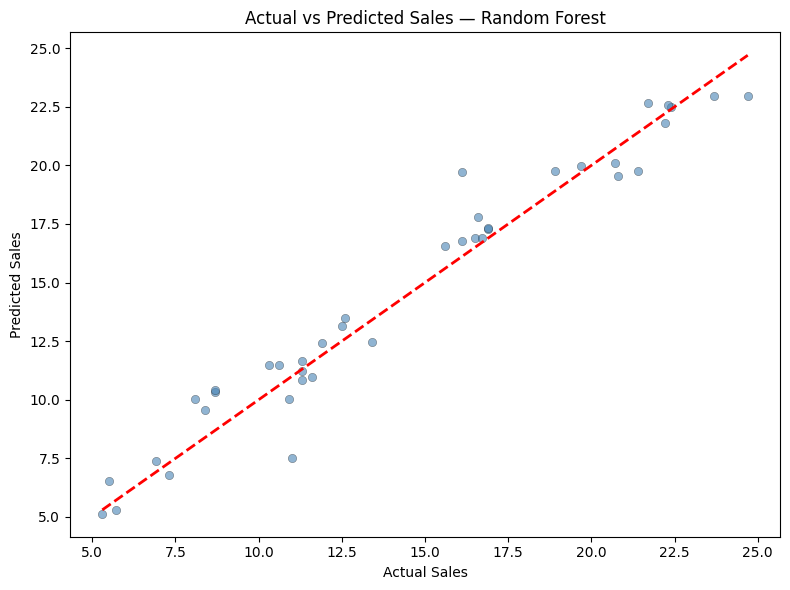

✅ Actual vs Predicted plot saved!


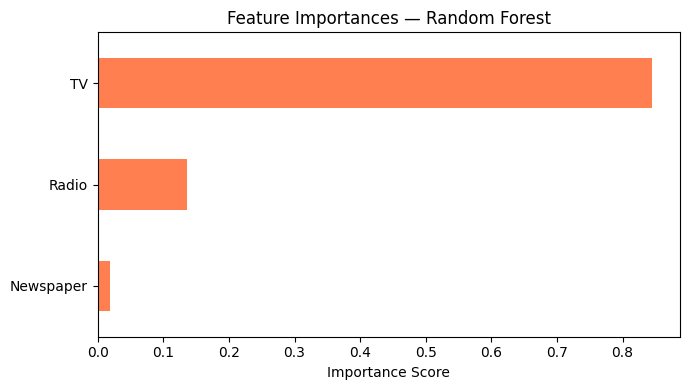

✅ Feature importance saved!

💰 Custom Prediction:
   TV=200, Radio=30, Newspaper=10
   Predicted Sales → 18.55 units


In [1]:
# =============================================================
# TASK 4 - SALES PREDICTION USING PYTHON
# CodSoft Data Science Internship
# Dataset: advertising.csv (200 rows, 4 columns)
# Features: TV, Radio, Newspaper → Predict: Sales
# =============================================================

# ── STEP 1: Upload & Load Dataset ────────────────────────────
from google.colab import files
import io, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings("ignore")

uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(io.BytesIO(uploaded[filename]))
print("✅ Dataset loaded:", df.shape)
print(df.head())


# ── STEP 2: EDA ───────────────────────────────────────────────
print("\n📋 Missing Values:")
print(df.isnull().sum())

print("\n📈 Statistics:")
print(df.describe())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Sales Prediction EDA', fontsize=16, fontweight='bold')

# TV vs Sales
axes[0,0].scatter(df['TV'], df['Sales'], color='steelblue', alpha=0.6)
axes[0,0].set_xlabel('TV Advertising Budget')
axes[0,0].set_ylabel('Sales')
axes[0,0].set_title('TV Budget vs Sales')

# Radio vs Sales
axes[0,1].scatter(df['Radio'], df['Sales'], color='coral', alpha=0.6)
axes[0,1].set_xlabel('Radio Advertising Budget')
axes[0,1].set_ylabel('Sales')
axes[0,1].set_title('Radio Budget vs Sales')

# Newspaper vs Sales
axes[1,0].scatter(df['Newspaper'], df['Sales'], color='green', alpha=0.6)
axes[1,0].set_xlabel('Newspaper Advertising Budget')
axes[1,0].set_ylabel('Sales')
axes[1,0].set_title('Newspaper Budget vs Sales')

# Correlation Heatmap
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,1])
axes[1,1].set_title('Correlation Heatmap')

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plots saved!")


# ── STEP 3: Train / Test Split ───────────────────────────────
from sklearn.model_selection import train_test_split

X = df[['TV', 'Radio', 'Newspaper']]
y = df['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\n📐 Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")


# ── STEP 4: Train Models ──────────────────────────────────────
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_preds = lr.predict(X_test)
lr_r2  = r2_score(y_test, lr_preds)
lr_mae = mean_absolute_error(y_test, lr_preds)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)
rf_r2  = r2_score(y_test, rf_preds)
rf_mae = mean_absolute_error(y_test, rf_preds)

print(f"\n🔵 Linear Regression  → R² Score: {lr_r2:.4f} | MAE: {lr_mae:.4f}")
print(f"🟢 Random Forest      → R² Score: {rf_r2:.4f} | MAE: {rf_mae:.4f}")


# ── STEP 5: Evaluate Best Model ──────────────────────────────
print(f"\n📊 Random Forest Evaluation:")
print(f"   R² Score : {rf_r2:.4f}  (closer to 1.0 = better)")
print(f"   MAE      : {rf_mae:.4f}  (average error in sales units)")
print(f"   RMSE     : {np.sqrt(mean_squared_error(y_test, rf_preds)):.4f}")

# Actual vs Predicted
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(y_test, rf_preds, alpha=0.6, color='steelblue', edgecolors='k', linewidths=0.3)
ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax.set_xlabel('Actual Sales')
ax.set_ylabel('Predicted Sales')
ax.set_title('Actual vs Predicted Sales — Random Forest')
plt.tight_layout()
plt.savefig('actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Actual vs Predicted plot saved!")


# ── STEP 6: Feature Importance ───────────────────────────────
feat_imp = pd.Series(rf.feature_importances_,
                     index=['TV', 'Radio', 'Newspaper']).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(7, 4))
feat_imp.plot(kind='barh', color='coral', ax=ax)
ax.set_title('Feature Importances — Random Forest')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Feature importance saved!")


# ── STEP 7: Predict Custom Advertising Budget ────────────────
# TV=200, Radio=30, Newspaper=10
new_budget = pd.DataFrame({
    'TV':        [200],
    'Radio':     [30],
    'Newspaper': [10]
})

pred_sales = rf.predict(new_budget)[0]
print(f"\n💰 Custom Prediction:")
print(f"   TV=200, Radio=30, Newspaper=10")
print(f"   Predicted Sales → {pred_sales:.2f} units")

